In [9]:
import os, re, json, gc, shutil, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras
from keras import layers, models

from google.colab import drive

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/dataset/npy_chunks/"
SAVE_ROOT = Path("/content/drive/MyDrive/DeepJSCCQ_Models")
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

RESIZE_TO = 64
IMG_H = IMG_W = 64
IMG_C = 3
N_SRC = IMG_H * IMG_W * IMG_C

assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"

print("DATA_DIR:", DATA_DIR)
print("SAVE_ROOT:", SAVE_ROOT)
print("N_SRC:", N_SRC)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/Colab Notebooks/dataset/npy_chunks/
SAVE_ROOT: /content/drive/MyDrive/DeepJSCCQ_Models
N_SRC: 12288


In [11]:
resample = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR

x_files = sorted(
    [f for f in os.listdir(DATA_DIR) if f.startswith("X_batch") and f.endswith(".npy")],
    key=lambda f: int(re.search(r"\d+", f).group())
)

if not x_files:
    raise FileNotFoundError(f"No X_batch .npy files found in {DATA_DIR}")

print(f"Found {len(x_files)} chunk files")

all_images_list = []

for i, fname in enumerate(x_files):
    arr = np.load(os.path.join(DATA_DIR, fname))

    if arr.max() <= 1.0:
        arr = (arr * 255.0).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)

    resized = np.zeros((len(arr), RESIZE_TO, RESIZE_TO, 3), dtype=np.uint8)

    for j, img in enumerate(arr):
        resized[j] = np.array(
            Image.fromarray(img).resize((RESIZE_TO, RESIZE_TO), resample)
        )

    all_images_list.append(resized)
    print(f"[{i+1}/{len(x_files)}] {fname} -> {resized.shape}")

all_images = np.concatenate(all_images_list, axis=0)
del all_images_list

TOTAL = len(all_images)

print("Loaded images:", all_images.shape, all_images.dtype)
print("TOTAL:", TOTAL)

Found 39 chunk files
[1/39] X_batch_0.npy -> (500, 64, 64, 3)
[2/39] X_batch_1.npy -> (500, 64, 64, 3)
[3/39] X_batch_2.npy -> (500, 64, 64, 3)
[4/39] X_batch_3.npy -> (500, 64, 64, 3)
[5/39] X_batch_4.npy -> (500, 64, 64, 3)
[6/39] X_batch_5.npy -> (500, 64, 64, 3)
[7/39] X_batch_6.npy -> (500, 64, 64, 3)
[8/39] X_batch_7.npy -> (500, 64, 64, 3)
[9/39] X_batch_8.npy -> (500, 64, 64, 3)
[10/39] X_batch_9.npy -> (500, 64, 64, 3)
[11/39] X_batch_10.npy -> (500, 64, 64, 3)
[12/39] X_batch_11.npy -> (500, 64, 64, 3)
[13/39] X_batch_12.npy -> (500, 64, 64, 3)
[14/39] X_batch_13.npy -> (500, 64, 64, 3)
[15/39] X_batch_14.npy -> (500, 64, 64, 3)
[16/39] X_batch_15.npy -> (500, 64, 64, 3)
[17/39] X_batch_16.npy -> (500, 64, 64, 3)
[18/39] X_batch_17.npy -> (500, 64, 64, 3)
[19/39] X_batch_18.npy -> (500, 64, 64, 3)
[20/39] X_batch_19.npy -> (500, 64, 64, 3)
[21/39] X_batch_20.npy -> (500, 64, 64, 3)
[22/39] X_batch_21.npy -> (500, 64, 64, 3)
[23/39] X_batch_22.npy -> (500, 64, 64, 3)
[24/39] X

In [32]:
CONFIGS = [

    {"name":"c48_m64_s10",  "C_OUT":48,  "M":64, "SNR_DB":10},

    {"name":"c64_m64_s10",  "C_OUT":64,  "M":64, "SNR_DB":10},

    {"name":"c96_m64_s10",  "C_OUT":96,  "M":64, "SNR_DB":10},

    {"name":"c128_m64_s10", "C_OUT":128, "M":64, "SNR_DB":10},

]

BATCH_SIZE = 32
EPOCHS = 100
STEPS = 200
H_LAT = W_LAT = IMG_H // 4

print("Configs ready:")
for cfg in CONFIGS:
    print(cfg)

Configs ready:
{'name': 'c48_m64_s10', 'C_OUT': 48, 'M': 64, 'SNR_DB': 10}
{'name': 'c64_m64_s10', 'C_OUT': 64, 'M': 64, 'SNR_DB': 10}
{'name': 'c96_m64_s10', 'C_OUT': 96, 'M': 64, 'SNR_DB': 10}
{'name': 'c128_m64_s10', 'C_OUT': 128, 'M': 64, 'SNR_DB': 10}


In [24]:
@keras.saving.register_keras_serializable(package="DeepJSCCQ")
class NormalizeInput(layers.Layer):
    def call(self, x):
        return x * 2.0 - 1.0

    def get_config(self):
        return super().get_config()


@keras.saving.register_keras_serializable(package="DeepJSCCQ")
class SoftQuantizer(layers.Layer):
    def __init__(self, M=16, sigma_q=10.0, **kwargs):
        super().__init__(**kwargs)
        self.M = int(M)
        self.sigma_q = float(sigma_q)

        m = int(np.sqrt(self.M))
        if m * m != self.M:
            raise ValueError("M must be a square QAM size, e.g. 16 or 64.")

        points = np.arange(-(m - 1), m, 2, dtype=np.float32)
        I, Q = np.meshgrid(points, points)
        const = np.stack([I.flatten(), Q.flatten()], axis=1)
        avg_power = np.mean(np.sum(const**2, axis=1))
        self.constellation = tf.constant(const / np.sqrt(avg_power), dtype=tf.float32)

    def call(self, z):
        shape = tf.shape(z)
        z_flat = tf.reshape(z, [-1, 2])
        const = tf.expand_dims(self.constellation, 0)
        z_ex = tf.expand_dims(z_flat, 1)
        dist = tf.reduce_sum(tf.square(z_ex - const), axis=2)
        weights = tf.nn.softmax(-self.sigma_q * dist, axis=1)
        z_soft = tf.reduce_sum(tf.expand_dims(weights, 2) * const, axis=1)
        return tf.reshape(z_soft, shape)

    def get_config(self):
        config = super().get_config()
        config.update({"M": self.M, "sigma_q": self.sigma_q})
        return config


@keras.saving.register_keras_serializable(package="DeepJSCCQ")
class HardQuantizer(layers.Layer):
    def __init__(self, M=16, **kwargs):
        super().__init__(**kwargs)
        self.M = int(M)

        m = int(np.sqrt(self.M))
        if m * m != self.M:
            raise ValueError("M must be a square QAM size, e.g. 16 or 64.")

        points = np.arange(-(m - 1), m, 2, dtype=np.float32)
        I, Q = np.meshgrid(points, points)
        const = np.stack([I.flatten(), Q.flatten()], axis=1)
        avg_power = np.mean(np.sum(const**2, axis=1))
        self.constellation = tf.constant(const / np.sqrt(avg_power), dtype=tf.float32)

    def call(self, z):
        shape = tf.shape(z)
        z_flat = tf.reshape(z, [-1, 2])
        const = tf.expand_dims(self.constellation, 0)
        z_ex = tf.expand_dims(z_flat, 1)
        dist = tf.reduce_sum(tf.square(z_ex - const), axis=2)
        idx = tf.argmin(dist, axis=1)
        z_hard = tf.gather(self.constellation, idx)
        z_hard = tf.stop_gradient(z_hard - z_flat) + z_flat
        return tf.reshape(z_hard, shape)

    def get_config(self):
        config = super().get_config()
        config.update({"M": self.M})
        return config


@keras.saving.register_keras_serializable(package="DeepJSCCQ")
class AWGN_Q(layers.Layer):
    def __init__(self, snr_db, **kwargs):
        super().__init__(**kwargs)
        self.snr_db = float(snr_db)

    def call(self, z):
        snr_linear = 10.0 ** (self.snr_db / 10.0)
        noise_std = tf.sqrt(1.0 / (2.0 * snr_linear))
        noise = tf.random.normal(tf.shape(z), stddev=noise_std)
        return z + noise

    def get_config(self):
        config = super().get_config()
        config.update({"snr_db": self.snr_db})
        return config


def build_encoder(C_OUT):
    inp = layers.Input(shape=(IMG_H, IMG_W, IMG_C))
    x = NormalizeInput()(inp)

    x = layers.Conv2D(16, 5, strides=2, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(32, 5, strides=2, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(32, 5, strides=1, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(32, 5, strides=1, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(C_OUT, 5, strides=1, padding="same")(x)
    latent = layers.PReLU(shared_axes=[1, 2])(x)

    return models.Model(inp, latent, name=f"encoder_cout{C_OUT}")


def build_decoder(C_OUT):
    inp = layers.Input(shape=(H_LAT, W_LAT, C_OUT))

    x = layers.Conv2DTranspose(32, 5, strides=1, padding="same")(inp)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2DTranspose(32, 5, strides=1, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2DTranspose(32, 5, strides=1, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2DTranspose(16, 5, strides=2, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    out = layers.Conv2DTranspose(3, 5, strides=2, padding="same", activation="sigmoid")(x)

    return models.Model(inp, out, name=f"decoder_cout{C_OUT}")


def build_jscc_q(C_OUT, snr_db, M=16):
    inp = layers.Input(shape=(IMG_H, IMG_W, IMG_C))

    x = NormalizeInput()(inp)

    x = layers.Conv2D(16, 5, strides=2, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(32, 5, strides=2, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(32, 5, strides=1, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(32, 5, strides=1, padding="same")(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(C_OUT, 5, strides=1, padding="same")(x)
    latent = layers.PReLU(shared_axes=[1, 2])(x)

    z = SoftQuantizer(M=M, sigma_q=10.0)(latent)
    y = AWGN_Q(snr_db)(z)

    x_dec = layers.Conv2DTranspose(32, 5, strides=1, padding="same")(y)
    x_dec = layers.PReLU(shared_axes=[1, 2])(x_dec)

    x_dec = layers.Conv2DTranspose(32, 5, strides=1, padding="same")(x_dec)
    x_dec = layers.PReLU(shared_axes=[1, 2])(x_dec)

    x_dec = layers.Conv2DTranspose(32, 5, strides=1, padding="same")(x_dec)
    x_dec = layers.PReLU(shared_axes=[1, 2])(x_dec)

    x_dec = layers.Conv2DTranspose(16, 5, strides=2, padding="same")(x_dec)
    x_dec = layers.PReLU(shared_axes=[1, 2])(x_dec)

    out = layers.Conv2DTranspose(3, 5, strides=2, padding="same", activation="sigmoid")(x_dec)

    enc = models.Model(inp, latent, name=f"enc_qam{M}_cout{C_OUT}_snr{snr_db}")
    dec = models.Model(y, out, name=f"dec_qam{M}_cout{C_OUT}_snr{snr_db}")
    full = models.Model(inp, out, name=f"full_qam{M}_cout{C_OUT}_snr{snr_db}")

    return full, enc, dec


def compute_psnr(orig, rec):
    mse = float(np.mean((orig - rec) ** 2))
    return 10.0 * np.log10(1.0 / mse) if mse > 1e-12 else 99.0

print("Model components ready.")

Model components ready.


In [25]:
def jscc_gen(batch_size=BATCH_SIZE):
    idx = np.arange(TOTAL)
    while True:
        np.random.shuffle(idx)
        for i in range(0, TOTAL - batch_size + 1, batch_size):
            b = all_images[idx[i:i + batch_size]].astype(np.float32) / 255.0
            yield b, b

train_ds = tf.data.Dataset.from_generator(
    lambda: jscc_gen(BATCH_SIZE),
    output_signature=(
        tf.TensorSpec(shape=(BATCH_SIZE, IMG_H, IMG_W, IMG_C), dtype=tf.float32),
        tf.TensorSpec(shape=(BATCH_SIZE, IMG_H, IMG_W, IMG_C), dtype=tf.float32),
    )
).prefetch(tf.data.AUTOTUNE)

print("Training dataset ready.")

Training dataset ready.


In [26]:
def train_and_save_one(cfg):
    tf.keras.backend.clear_session()
    gc.collect()

    C_OUT = cfg["C_OUT"]
    M = cfg["M"]
    SNR_DB = cfg["SNR_DB"]
    model_name = cfg["name"]

    MODEL_DIR = SAVE_ROOT / model_name
    if MODEL_DIR.exists():
        shutil.rmtree(MODEL_DIR)
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 80)
    print("Training Deep JSCC-Q")
    print(f"name   = {model_name}")
    print(f"C_OUT  = {C_OUT}")
    print(f"M      = {M}")
    print(f"SNR_DB = {SNR_DB}")
    print("=" * 80)

    full, enc, dec = build_jscc_q(C_OUT=C_OUT, snr_db=SNR_DB, M=M)

    full.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="mse"
    )

    callbacks = [
        keras.callbacks.ReduceLROnPlateau(
            monitor="loss",
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="loss",
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
    ]

    history = full.fit(
        train_ds,
        steps_per_epoch=STEPS,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # Save models
    full_path = str(MODEL_DIR / "full.keras")
    enc_path = str(MODEL_DIR / "encoder.keras")
    dec_path = str(MODEL_DIR / "decoder.keras")

    full.save(full_path)
    enc.save(enc_path)
    dec.save(dec_path)

    # Save config and history
    with open(MODEL_DIR / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    with open(MODEL_DIR / "history.json", "w") as f:
        json.dump(history.history, f, indent=2)

    # Verify files exist
    assert os.path.exists(full_path), f"Missing file: {full_path}"
    assert os.path.exists(enc_path), f"Missing file: {enc_path}"
    assert os.path.exists(dec_path), f"Missing file: {dec_path}"

    print(f"\nSaved to: {MODEL_DIR}")
    print("Encoder:", enc_path)
    print("Decoder:", dec_path)

    del full, enc, dec
    gc.collect()
    tf.keras.backend.clear_session()

    return history.history

In [27]:
all_histories = {}

for cfg in CONFIGS:
    hist = train_and_save_one(cfg)
    all_histories[cfg["name"]] = hist

with open(SAVE_ROOT / "all_histories.json", "w") as f:
    json.dump(all_histories, f, indent=2)

print("\nAll models trained and saved.")
print("Folders created:")
for p in sorted(SAVE_ROOT.iterdir()):
    if p.is_dir():
        print(" -", p.name)


Training Deep JSCC-Q
name   = c24_m16_s10
C_OUT  = 24
M      = 16
SNR_DB = 10
Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0245 - learning_rate: 1.0000e-04
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0087 - learning_rate: 1.0000e-04
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0069 - learning_rate: 1.0000e-04
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0054 - learning_rate: 1.0000e-04
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0048 - learning_rate: 1.0000e-04
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0044 - learning_rate: 1.0000e-04
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0040 - learning_rate: 1.0000e-04
Epoch 9/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0037 - learning_rate: 1.0000e-04
Epoch 10/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.

In [28]:
test_cfg = CONFIGS[0]
test_dir = SAVE_ROOT / test_cfg["name"]

print("Loading:", test_dir)

enc = keras.models.load_model(str(test_dir / "encoder.keras"), compile=False)
dec = keras.models.load_model(str(test_dir / "decoder.keras"), compile=False)

sample = all_images[:1].astype(np.float32) / 255.0
z = enc.predict(sample, verbose=0)
rec = dec.predict(z, verbose=0)

print("Encoder output:", z.shape)
print("Decoder output:", rec.shape)
print("Latent stats:", np.min(z), np.max(z), np.mean(z))
print("Reconstruction stats:", np.min(rec), np.max(rec), np.mean(rec))

Loading: /content/drive/MyDrive/DeepJSCCQ_Models/c24_m16_s10
Encoder output: (1, 16, 16, 24)
Decoder output: (1, 64, 64, 3)
Latent stats: -0.46674696 2.9276464 0.47274736
Reconstruction stats: 0.08848458 0.80005693 0.20440747


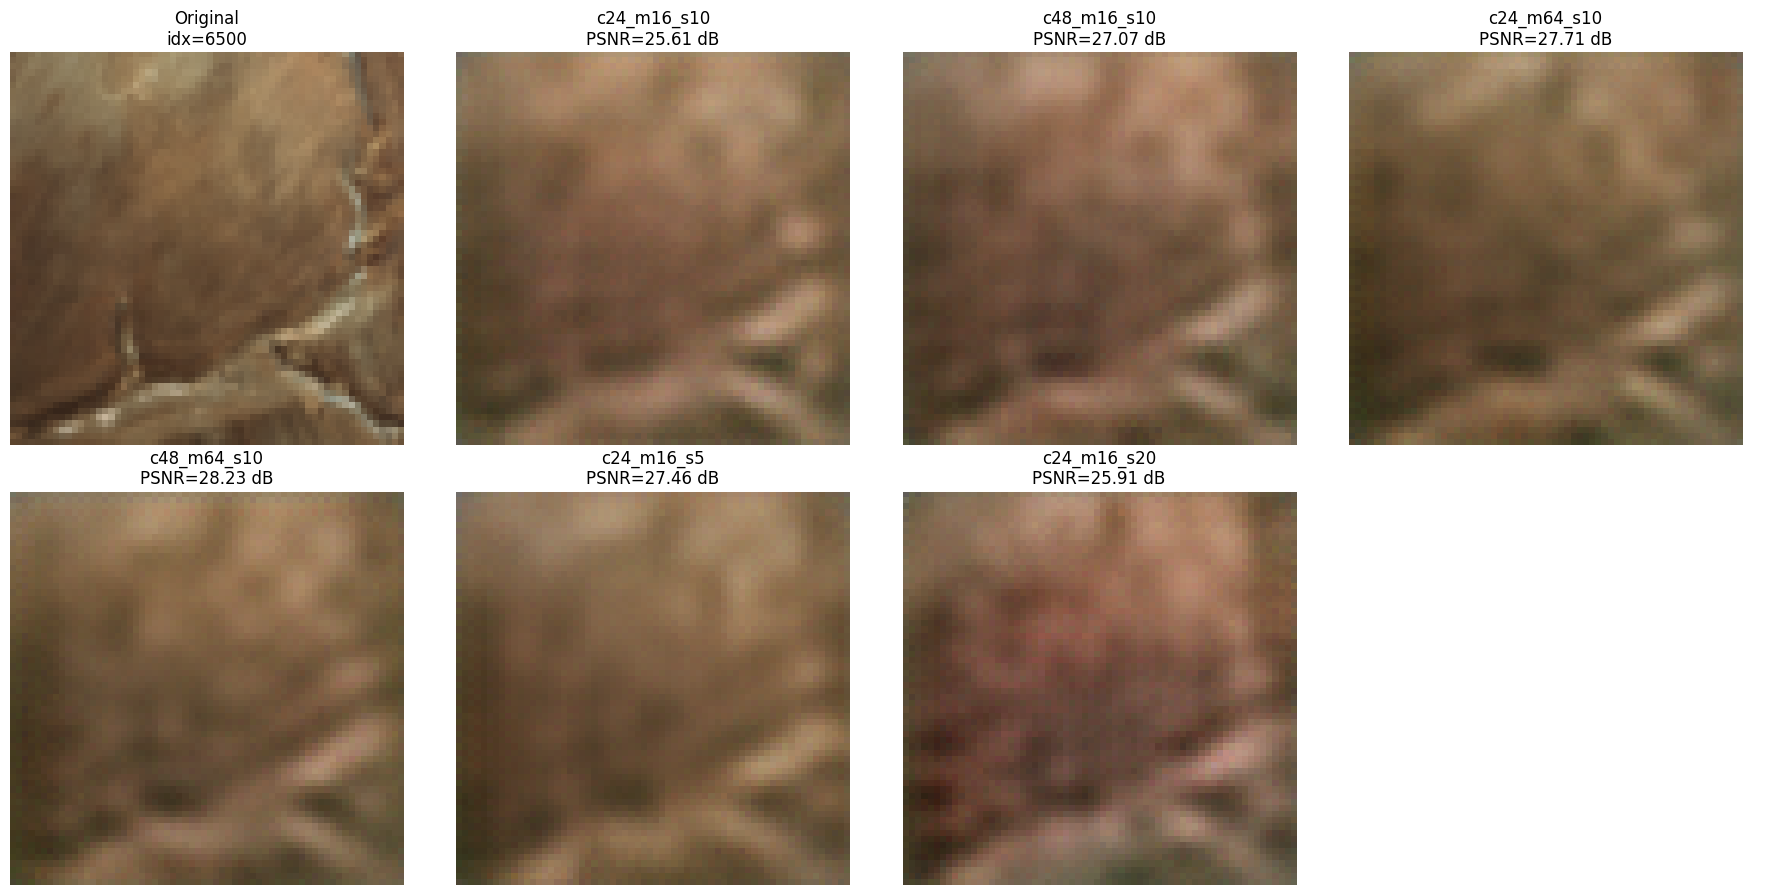

       name  C_OUT  M  train_SNR_DB  test_SNR_DB      MSE   PSNR_dB
c48_m64_s10     48 64            10           10 0.001505 28.225362
c24_m64_s10     24 64            10           10 0.001696 27.706637
 c24_m16_s5     24 16             5           10 0.001794 27.460659
c48_m16_s10     48 16            10           10 0.001962 27.072129
c24_m16_s20     24 16            20           10 0.002566 25.908041
c24_m16_s10     24 16            10           10 0.002747 25.611413

Saved: side_by_side_comparison.png
Saved: comparison_summary.csv


In [29]:
import pandas as pd

def eval_saved_model(enc, dec, x, M, snr_db):
    latent = enc.predict(x, verbose=0)
    latent_q = HardQuantizer(M=M)(latent).numpy()

    sigma = np.sqrt(1.0 / (2.0 * (10.0 ** (snr_db / 10.0))))
    noise = np.random.normal(0, sigma, latent_q.shape).astype(np.float32)
    rx = latent_q + noise

    rec = dec.predict(rx, verbose=0)
    rec = np.clip(rec, 0.0, 1.0)

    mse = float(np.mean((x - rec) ** 2))
    psnr = 10.0 * np.log10(1.0 / mse) if mse > 1e-12 else 99.0
    return rec[0], mse, psnr

EVAL_SNR_DB = 10
TEST_IDX = TOTAL // 3

x = all_images[TEST_IDX:TEST_IDX + 1].astype(np.float32) / 255.0
orig = x[0]

model_dirs = [SAVE_ROOT / cfg["name"] for cfg in CONFIGS]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

axes[0].imshow(orig)
axes[0].set_title(f"Original\nidx={TEST_IDX}")
axes[0].axis("off")

rows = []

for i, folder in enumerate(model_dirs, start=1):
    cfg = json.load(open(folder / "config.json"))
    enc = keras.models.load_model(str(folder / "encoder.keras"), compile=False)
    dec = keras.models.load_model(str(folder / "decoder.keras"), compile=False)

    recon, mse, psnr = eval_saved_model(enc, dec, x, cfg["M"], EVAL_SNR_DB)
    rows.append({
        "name": cfg["name"],
        "C_OUT": cfg["C_OUT"],
        "M": cfg["M"],
        "train_SNR_DB": cfg["SNR_DB"],
        "test_SNR_DB": EVAL_SNR_DB,
        "MSE": mse,
        "PSNR_dB": psnr,
    })

    axes[i].imshow(recon)
    axes[i].set_title(f"{cfg['name']}\nPSNR={psnr:.2f} dB")
    axes[i].axis("off")

for j in range(1 + len(model_dirs), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(SAVE_ROOT / "side_by_side_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

df = pd.DataFrame(rows).sort_values("PSNR_dB", ascending=False)
print(df.to_string(index=False))
df.to_csv(SAVE_ROOT / "comparison_summary.csv", index=False)
print("\nSaved: side_by_side_comparison.png")
print("Saved: comparison_summary.csv")

Loading: c24_m16_s10
Loading: c48_m16_s10
Loading: c24_m64_s10
Loading: c48_m64_s10
Loading: c24_m16_s5
Loading: c24_m16_s20


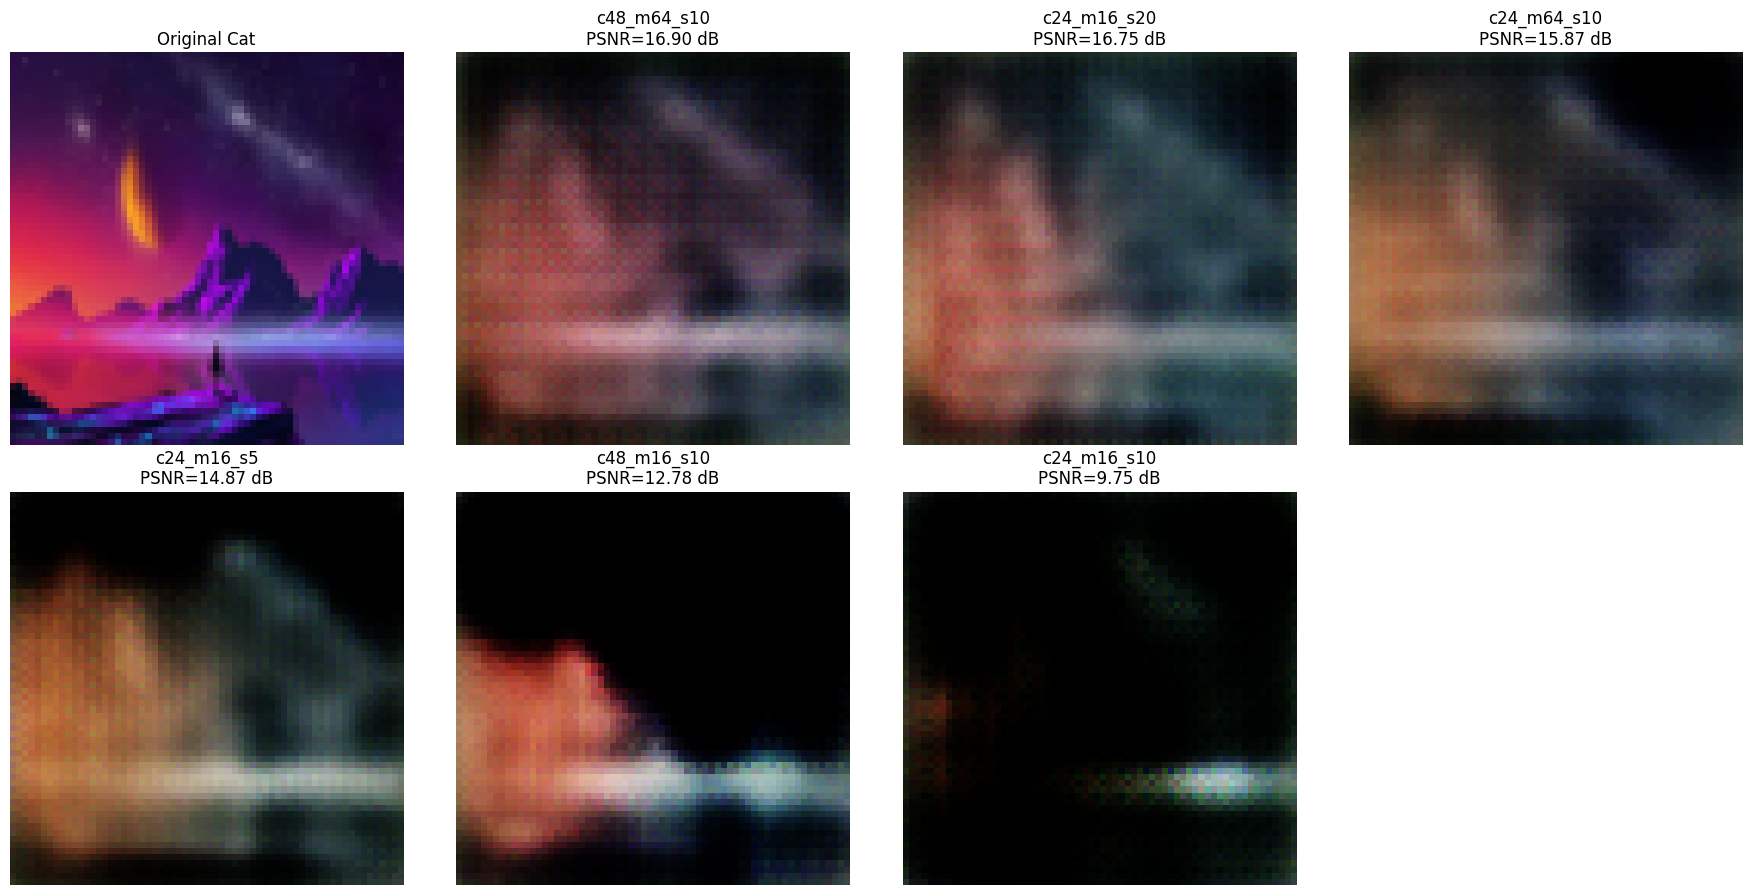


===== RANKING =====

c48_m64_s10      16.90 dB
c24_m16_s20      16.75 dB
c24_m64_s10      15.87 dB
c24_m16_s5       14.87 dB
c48_m16_s10      12.78 dB
c24_m16_s10      9.75 dB


In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import keras

# =====================================================
# SETTINGS
# =====================================================

TEST_IMAGE = "test.jpg"
EVAL_SNR_DB = 10

# =====================================================
# LOAD IMAGE
# =====================================================

img = Image.open(TEST_IMAGE).convert("RGB")
img = img.resize((64, 64))

x = np.array(img).astype(np.float32) / 255.0
x = np.expand_dims(x, axis=0)

# =====================================================
# HARD QUANTIZER
# =====================================================

class HardQuantizer(tf.keras.layers.Layer):
    def __init__(self, M=16, **kwargs):
        super().__init__(**kwargs)

        self.M = M

        m = int(np.sqrt(M))

        points = np.arange(-(m - 1), m, 2, dtype=np.float32)

        I, Q = np.meshgrid(points, points)

        const = np.stack([I.flatten(), Q.flatten()], axis=1)

        avg_power = np.mean(np.sum(const**2, axis=1))

        self.constellation = tf.constant(
            const / np.sqrt(avg_power),
            dtype=tf.float32
        )

    def call(self, z):

        s = tf.shape(z)

        zf = tf.reshape(z, [-1, 2])

        const = tf.expand_dims(self.constellation, axis=0)

        zex = tf.expand_dims(zf, axis=1)

        dist = tf.reduce_sum(tf.square(zex - const), axis=2)

        idx = tf.argmin(dist, axis=1)

        zh = tf.gather(self.constellation, idx)

        return tf.reshape(zh, s)

# =====================================================
# MODEL FOLDERS
# =====================================================

model_dirs = []

for cfg in CONFIGS:
    model_dirs.append(SAVE_ROOT / cfg["name"])

# =====================================================
# EVALUATION
# =====================================================

results = []

for folder in model_dirs:

    cfg = json.load(open(folder / "config.json"))

    print("Loading:", cfg["name"])

    enc = keras.models.load_model(
        str(folder / "encoder.keras"),
        compile=False
    )

    dec = keras.models.load_model(
        str(folder / "decoder.keras"),
        compile=False
    )

    latent = enc.predict(x, verbose=0)

    latent_q = HardQuantizer(M=cfg["M"])(latent).numpy()

    sigma = np.sqrt(
        1.0 /
        (2.0 * (10.0 ** (EVAL_SNR_DB / 10.0)))
    )

    noise = np.random.normal(
        0,
        sigma,
        latent_q.shape
    ).astype(np.float32)

    rx = latent_q + noise

    recon = dec.predict(rx, verbose=0)

    recon = np.clip(recon, 0.0, 1.0)

    mse = np.mean((x - recon) ** 2)

    psnr = 10.0 * np.log10(1.0 / mse)

    results.append(
        (
            cfg["name"],
            psnr,
            recon[0]
        )
    )

# =====================================================
# SORT BEST TO WORST
# =====================================================

results.sort(
    key=lambda z: z[1],
    reverse=True
)

# =====================================================
# DISPLAY
# =====================================================

cols = 4
rows = 2

plt.figure(figsize=(18, 9))

plt.subplot(rows, cols, 1)
plt.imshow(x[0])
plt.title("Original Cat")
plt.axis("off")

for i, (name, psnr, recon) in enumerate(results, start=2):

    plt.subplot(rows, cols, i)

    plt.imshow(recon)

    plt.title(
        f"{name}\nPSNR={psnr:.2f} dB"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# NUMERIC RESULTS
# =====================================================

print("\n===== RANKING =====\n")

for name, psnr, _ in results:
    print(f"{name:15s}  {psnr:.2f} dB")

In [ ]:
EVAL_SNR_DB = 10
EVAL_IDS = np.linspace(0, TOTAL - 1, 10, dtype=int).tolist()

avg_rows = []

for folder in model_dirs:
    cfg = json.load(open(folder / "config.json"))
    enc = keras.models.load_model(str(folder / "encoder.keras"), compile=False)
    dec = keras.models.load_model(str(folder / "decoder.keras"), compile=False)

    psnrs = []
    mses = []

    for idx in EVAL_IDS:
        x = all_images[idx:idx + 1].astype(np.float32) / 255.0
        _, mse, psnr = eval_saved_model(enc, dec, x, cfg["M"], EVAL_SNR_DB)
        psnrs.append(psnr)
        mses.append(mse)

    avg_rows.append({
        "name": cfg["name"],
        "C_OUT": cfg["C_OUT"],
        "M": cfg["M"],
        "train_SNR_DB": cfg["SNR_DB"],
        "test_SNR_DB": EVAL_SNR_DB,
        "avg_MSE": float(np.mean(mses)),
        "avg_PSNR_dB": float(np.mean(psnrs)),
    })

avg_df = pd.DataFrame(avg_rows).sort_values("avg_PSNR_dB", ascending=False)
print(avg_df.to_string(index=False))
avg_df.to_csv(SAVE_ROOT / "average_comparison_summary.csv", index=False)
print("\nSaved: average_comparison_summary.csv")